# Práctica 3 PVC
### Natalia Martínez García y Lucía Vega Navarrete - Grupo 1.1

## Ejercicio 2 - Reconocimientro de objetos 

In [17]:
from pathlib import Path
import numpy as np
from skimage.io import imread
from skimage.color import rgb2hsv, rgb2gray
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

### Carga del dataset

Antes de trabajar con los modelos de aprendizaje automático, es necesario garantizar que todas las imágenes del conjunto de datos tengan las mismas dimensiones. En este ejercicio, las imágenes pertenecen a cuatro categorías (“elephant”, “emu”, “flamingo” y “rhino”) y, aunque presentan resoluciones similares, no son idénticas entre sí.

Una opción habitual sería redimensionar todas las imágenes a un tamaño común; sin embargo, este proceso modifica la geometría del objeto y puede suponer una pérdida significativa de información, especialmente en un problema de reconocimiento donde la forma y los contornos son fundamentales.

Siguiendo la recomendación del profesor, optamos por un enfoque más adecuado: normalizar las dimensiones mediante padding. Este procedimiento consiste en:

1. Calcular la altura y anchura máximas presentes en el conjunto.

2. Para cada imagen que no alcance dicho tamaño, añadir bordes (rellenos con valor cero) hasta igualarla.

3. Conservar así la información visual original sin deformaciones ni escalados.

De este modo, obtenemos un conjunto homogéneo de imágenes que pueden posteriormente aplanarse o utilizarse para extraer características, asegurando que cada vector de entrada tenga exactamente la misma longitud. Este preprocesado es especialmente adecuado para los clasificadores clásicos que emplearemos posteriormente (KNN, SVM, Random Forest…), los cuales requieren entradas de dimensión fija.

In [36]:

# Ruta al dataset
dataset_path = Path("DataSet_2/objects")
images_path = dataset_path / "images" 
masks_path  = dataset_path / "masks"

# Listas donde almacenamos imágenes, máscaras y etiquetas (sin redimensionar aún)
raw_images = []
raw_masks  = []
raw_labels = [] 

# 1. Carga de imágenes y máscaras tal cual (solo normalización de canales)

for class_folder in images_path.iterdir():
    if class_folder.is_dir():
        masks_class_folder = masks_path / class_folder.name
        
        images_files = sorted(class_folder.glob("*.jpg"))
        masks_files  = sorted(masks_class_folder.glob("*.png"))

        print(class_folder.name, len(images_files), len(masks_files))

        for image_file, mask_file in zip(images_files, masks_files):

            # ----------- Imagen -----------
            img = imread(image_file)

            # Normalizar a RGB
            if img.ndim == 2:  # gris → 3 canales
                img = np.stack([img]*3, axis=-1)
            elif img.ndim == 3 and img.shape[2] > 3:  # RGBA → RGB
                img = img[:, :, :3]

            # ----------- Máscara -----------
            mask = imread(mask_file)
            if mask.ndim == 3:       # si viene en RGB
                mask = mask[:, :, 0]
            mask_bin = (mask > 128).astype(np.uint8)

            raw_images.append(img)
            raw_masks.append(mask_bin)
            raw_labels.append(class_folder.name)   # <<< guardamos la clase de la imagen

# Convertimos a np.array de objetos para manipular tamaños
raw_images = np.array(raw_images, dtype=object)
raw_masks  = np.array(raw_masks,  dtype=object)
raw_labels = np.array(raw_labels)               # <<< etiquetas como array

# 2. Calcular tamaño máximo (alto y ancho) 
max_h = max(img.shape[0] for img in raw_images)
max_w = max(img.shape[1] for img in raw_images)

print("Tamaño máximo encontrado:", max_h, "x", max_w)

# 3. Aplicar padding a imágenes y máscaras 
padded_images = []
padded_masks  = []

for img, mask in zip(raw_images, raw_masks):

    h, w = img.shape[:2]

    pad_h = max_h - h
    pad_w = max_w - w

    pad_top    = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left   = pad_w // 2
    pad_right  = pad_w - pad_left

    # Imagen RGB
    img_padded = np.pad(
        img,
        ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
        mode='constant',
        constant_values=0
    )

    # Máscara (H, W)
    mask_padded = np.pad(
        mask,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode='constant',
        constant_values=0
    )

    padded_images.append(img_padded)
    padded_masks.append(mask_padded)

#  4. Convertir a arrays finales 
images = np.stack(padded_images, axis=0)  # (N, max_h, max_w, 3)
masks  = np.stack(padded_masks, axis=0)   # (N, max_h, max_w)
labels = raw_labels                       # (N,) clases en texto

# ==== 5. Comprobación final ====
print(f"Shape imágenes: {images.shape}")
print(f"Shape máscaras: {masks.shape}")
print(f"Ejemplo de etiquetas:", np.unique(labels, return_counts=True))

elephant 64 64
emu 53 53
flamingo 67 67
rhino 59 59
Tamaño máximo encontrado: 300 x 300
Shape imágenes: (243, 300, 300, 3)
Shape máscaras: (243, 300, 300)
Ejemplo de etiquetas: (array(['elephant', 'emu', 'flamingo', 'rhino'], dtype='<U8'), array([64, 53, 67, 59]))


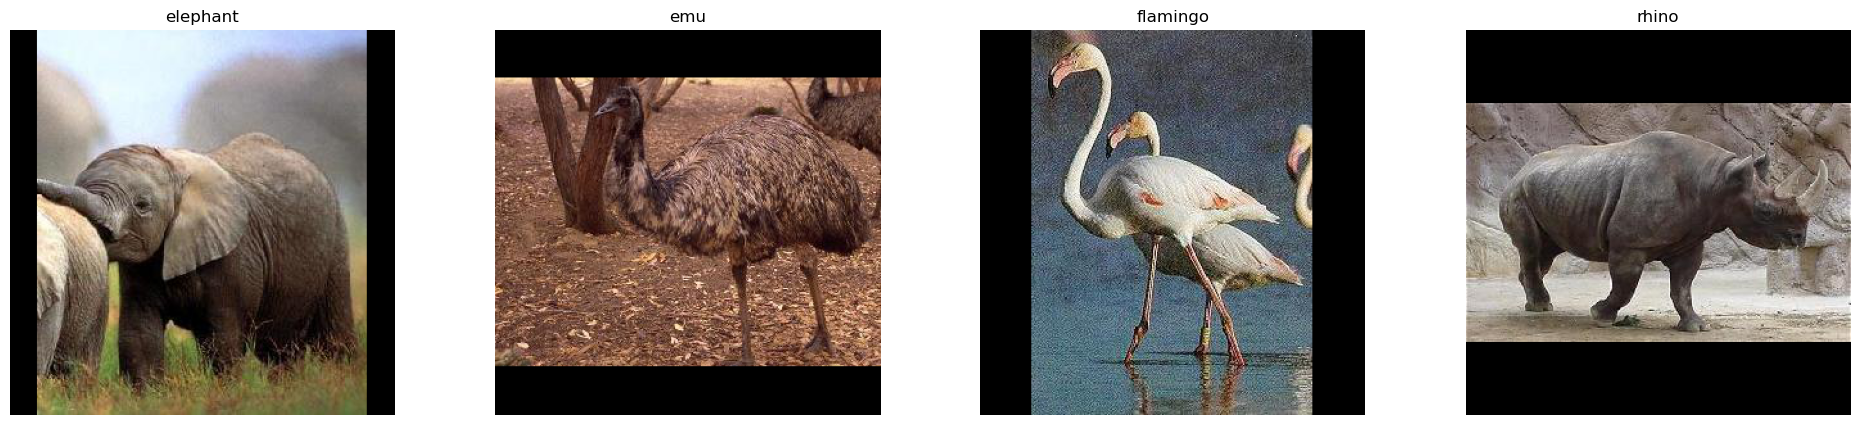

In [ ]:
# Ver imágenes después del padding solo para comprobar que se hizo bien y no se deforman

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].imshow(images[56])
axes[0].set_title(labels[56])
axes[0].axis('off')

axes[1].imshow(images[90])
axes[1].set_title(labels[90])
axes[1].axis('off')

axes[2].imshow(images[160])
axes[2].set_title(labels[160])
axes[2].axis('off')

axes[3].imshow(images[230])
axes[3].set_title(labels[230])
axes[3].axis('off')

plt.show()

### División de datos

In [3]:
# Partición en train / val / test usando índices aleatorios
n_total = len(images) 
indices = np.random.permutation(n_total)

# Aproximadamente 60% / 20% / 20%
n_test = int(0.2 * n_total)   # ~ 20% para test
n_val  = int(0.2 * n_total)   # ~ 20% para validación
n_train = n_total - n_test - n_val  # el resto para entrenamiento

# Dividimos el dataset por índices
test_indices  = indices[:n_test]
val_indices   = indices[n_test:n_test + n_val]
train_indices = indices[n_test + n_val:]

# Imágenes
X_test  = images[test_indices]
X_val   = images[val_indices]
X_train = images[train_indices]

# Máscaras (por si luego queréis recortar objeto, pero aquí NO las usamos como etiqueta)
masks_test  = masks[test_indices]
masks_val   = masks[val_indices]
masks_train = masks[train_indices]

# Etiquetas de clase
y_test_raw  = labels[test_indices]
y_val_raw   = labels[val_indices]
y_train_raw = labels[train_indices]

print(f"Total: {n_total} imágenes")
print(f"Train: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test: {len(X_test)} imágenes")

print("Clases en train:", np.unique(y_train_raw, return_counts=True))


Total: 243 imágenes
Train: 147 imágenes
Validación: 48 imágenes
Test: 48 imágenes
Clases en train: (array(['elephant', 'emu', 'flamingo', 'rhino'], dtype='<U8'), array([39, 27, 41, 40]))


### Extracción de características

In [ ]:
from skimage.color import rgb2gray
from skimage.feature import hog
import numpy as np

def extract_features_set(X):
    features_list = []

    for img in X:
        img_float = img.astype(np.float32) / 255.0

        # 1) Histogramas de color (16 bins por canal)
        hist_feats = []
        for c in range(3):
            channel = img_float[:, :, c]
            hist, _ = np.histogram(channel, bins=16, range=(0, 1), density=True)
            hist_feats.extend(hist)

        # 2) HOG sobre la imagen en gris
        gray = rgb2gray(img_float)
        hog_feat = hog(
            gray,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            orientations=9,
            block_norm='L2-Hys',
            feature_vector=True
        )

        feat_vector = np.concatenate([hist_feats, hog_feat])
        features_list.append(feat_vector)

    return np.array(features_list)

X_train_feat = extract_features_set(X_train)
X_val_feat   = extract_features_set(X_val)
X_test_feat  = extract_features_set(X_test)

print("Train features:", X_train_feat.shape)
print("Val features:  ", X_val_feat.shape)
print("Test features: ", X_test_feat.shape)

AttributeError: module 'matplotlib' has no attribute 'plot'

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Codificamos las etiquetas con las 4 clases originales
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_raw)
y_val_enc   = le.transform(y_val_raw)
y_test_enc  = le.transform(y_test_raw)

print("Clases codificadas:", le.classes_)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train_feat, y_train_enc)
print("Modelo RandomForest entrenado.")


Clases codificadas: ['elephant' 'emu' 'flamingo' 'rhino']
Modelo RandomForest entrenado.


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# === VALIDACIÓN ===
y_val_pred = rf.predict(X_val_feat)

print("=== VALIDACIÓN ===")
print("Accuracy:", accuracy_score(y_val_enc, y_val_pred))
print()
print("Classification Report (validación):")
print(classification_report(y_val_enc, y_val_pred, target_names=le.classes_))

print("Matriz de confusión (validación):")
print(confusion_matrix(y_val_enc, y_val_pred))

# === TEST ===
y_test_pred = rf.predict(X_test_feat)

print("\n=== TEST ===")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred))
print()
print("Classification Report (test):")
print(classification_report(y_test_enc, y_test_pred, target_names=le.classes_))

print("Matriz de confusión (test):")
print(confusion_matrix(y_test_enc, y_test_pred))


=== VALIDACIÓN ===
Accuracy: 0.6458333333333334

Classification Report (validación):
              precision    recall  f1-score   support

    elephant       0.64      0.54      0.58        13
         emu       0.50      0.42      0.45        12
    flamingo       0.80      0.73      0.76        11
       rhino       0.65      0.92      0.76        12

    accuracy                           0.65        48
   macro avg       0.65      0.65      0.64        48
weighted avg       0.64      0.65      0.64        48

Matriz de confusión (validación):
[[ 7  1  1  4]
 [ 4  5  1  2]
 [ 0  3  8  0]
 [ 0  1  0 11]]

=== TEST ===
Accuracy: 0.6666666666666666

Classification Report (test):
              precision    recall  f1-score   support

    elephant       0.70      0.58      0.64        12
         emu       0.71      0.36      0.48        14
    flamingo       0.81      0.87      0.84        15
       rhino       0.47      1.00      0.64         7

    accuracy                           